<a href="https://colab.research.google.com/github/pitawahyu11/Wine-Quality-Classification/blob/main/hasilprediksi_047.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality Classification

Bertujuan untuk membangun model machine learning
dalam memprediksi kualitas wine berdasarkan karakteristik kimia wine.

Model yang digunakan adalah Random Forest Classifier
dengan tahapan preprocessing, scaling, training, evaluasi,
dan deployment pada data testing.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

# Load data
df_train = pd.read_csv("/content/data_training.csv")
df_test  = pd.read_csv("/content/data_testing.csv")

print(df_train.shape, df_test.shape)
print(df_train.head())
print(df_train.isnull().sum())
print(df_train['quality'].value_counts().sort_index())



(857, 13) (286, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.3             0.740         0.08             1.7      0.094   
1            8.1             0.575         0.22             2.1      0.077   
2           10.1             0.430         0.40             2.6      0.092   
3           12.9             0.500         0.55             2.8      0.072   
4            8.4             0.360         0.32             2.2      0.081   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  45.0  0.99576  3.24       0.50   
1                 12.0                  65.0  0.99670  3.29       0.51   
2                 13.0                  52.0  0.99834  3.22       0.64   
3                  7.0                  24.0  1.00012  3.09       0.68   
4                 32.0                  79.0  0.99640  3.30       0.72   

   alcohol  quality    Id  
0      9.8        5  1366  
1      9.2

Dataset memiliki beberapa fitur numerik seperti acidity,
alcohol, sulphates, dan density yang digunakan untuk
memprediksi kualitas wine.

Tidak ditemukan tipe data kategorikal sehingga seluruh
fitur dapat langsung digunakan pada model machine learning.

## Data Cleaning

Tahap data cleaning dilakukan untuk memastikan tidak terdapat
missing values yang dapat mempengaruhi performa model.
Jika ditemukan missing values, maka dilakukan imputasi
menggunakan median.

In [20]:
# Imputasi missing value dengan median jika ada
for col in df_train.columns:
    if df_train[col].isnull().any():
        df_train[col].fillna(df_train[col].median(), inplace=True)

for col in df_test.columns:
    if df_test[col].isnull().any():
        df_test[col].fillna(df_train[col].median(), inplace=True)

# Pisah fitur dan target
features = [c for c in df_train.columns if c not in ['quality', 'Id']]

X_train = df_train[features]
y_train = df_train['quality']
X_test  = df_test[features]


##Model
Pada tahap ini, membuat model machine learning menggunakan RandomForestClassifier untuk memprediksi kualitas wine berdasarkan fitur-fitur yang tersedia pada dataset. StandardScaler untuk menstandarkan skala data agar model dapat bekerja lebih optimal. Selanjutnya dilakukan cross validation menggunakan StratifiedKFold untuk mengevaluasi performa model dan memastikan hasil akurasi lebih stabil. Setelah proses evaluasi selesai, model kemudian dilatih menggunakan seluruh data training agar dapat digunakan untuk melakukan prediksi pada data testing.

In [21]:
# Model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Training
pipeline.fit(X_train, y_train)


CV Accuracy: 0.6442 (+/- 0.0363)


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

Visualisasi distribusi kelas pada variabel quality menggunakan countplot. Visualisasi ini bertujuan untuk melihat jumlah data pada setiap kategori kualitas wine sehingga dapat diketahui apakah distribusi data seimbang atau terdapat kelas yang jumlahnya lebih dominan dibandingkan kelas lainnya.

## Visualisasi Distribusi Target

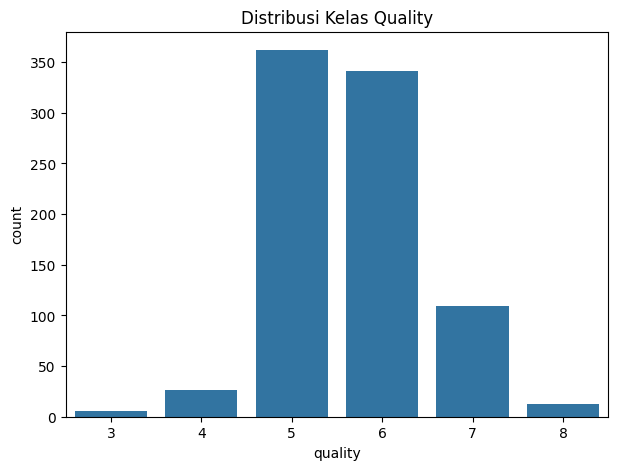

In [22]:
plt.figure(figsize=(7,5))
sns.countplot(x='quality', data=df_train)
plt.title("Distribusi Kelas Quality")
plt.show()

Distribusi kelas quality menunjukkan bahwa sebagian besar
data berada pada quality 5 dan 6. Hal ini menunjukkan
dataset bersifat tidak seimbang (imbalanced dataset).

## Evaluasi
Evaluasi model dilakukan menggunakan data training untuk melihat performa model dalam memprediksi kualitas wine. Pada tahap ini digunakan metrik accuracy untuk mengukur tingkat ketepatan prediksi model serta classification report untuk menampilkan nilai precision, recall, dan f1-score pada setiap kelas quality.

In [23]:
y_pred = pipeline.predict(X_train)
print(f"Train Accuracy: {accuracy_score(y_train, y_pred):.4f}")
print(classification_report(y_train, y_pred))


Train Accuracy: 1.0000
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



Hasil evaluasi menunjukkan bahwa model memiliki performa yang sangat baik pada data training dengan nilai accuracy sebesar 1.00 atau 100%. Nilai precision, recall, dan f1-score pada seluruh kelas juga mencapai 1.00, yang menunjukkan bahwa model mampu mengklasifikasikan seluruh data training dengan sangat tepat. Namun, hasil yang terlalu sempurna juga dapat mengindikasikan kemungkinan overfitting, yaitu model terlalu menghafal data training sehingga perlu diperhatikan performanya pada data lain melalui cross validation atau data testing.

## Confusion Matrix
Visualisasi confusion matrix digunakan untuk melihat perbandingan antara nilai aktual dan hasil prediksi model pada setiap kelas quality. Melalui visualisasi ini dapat diketahui seberapa baik model dalam melakukan klasifikasi serta melihat apakah masih terdapat kesalahan prediksi pada kelas tertentu.


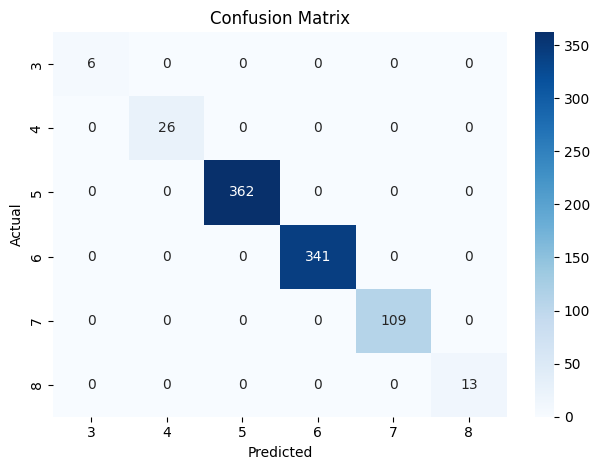

In [24]:
cm = confusion_matrix(y_train, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_train.unique()),
            yticklabels=sorted(y_train.unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Hasil confusion matrix menunjukkan bahwa model mampu memprediksi seluruh kelas quality dengan sangat baik karena seluruh data berada pada diagonal utama dan tidak terdapat kesalahan klasifikasi pada kelas lainnya. Hal ini menandakan bahwa prediksi model pada data training sangat akurat, namun performa yang terlalu sempurna juga perlu diwaspadai karena dapat mengindikasikan overfitting pada model.


##Feature Importance
Visualisasi feature importance digunakan untuk mengetahui fitur-fitur yang paling berpengaruh dalam proses prediksi kualitas wine. Semakin tinggi nilai importance suatu fitur, maka semakin besar kontribusinya terhadap hasil klasifikasi yang dilakukan oleh model Random Forest.


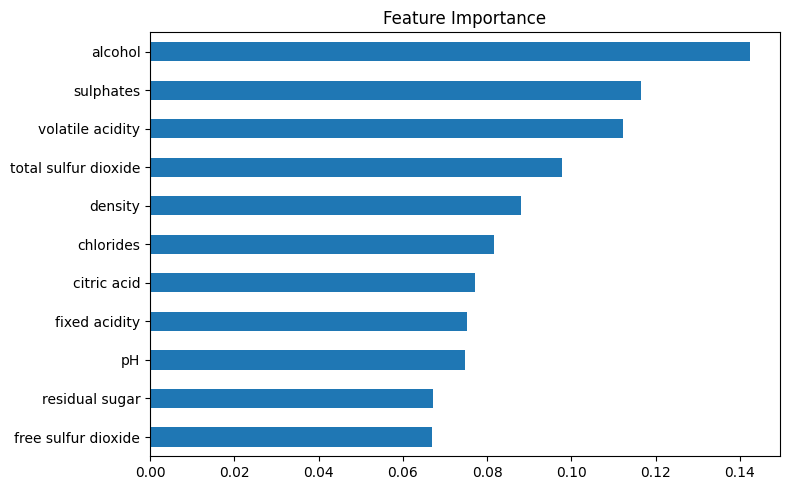

In [25]:
importances = pd.Series(pipeline.named_steps['clf'].feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8, 5), title="Feature Importance")
plt.tight_layout()
plt.show()

Hasil feature importance menunjukkan bahwa fitur alcohol memiliki pengaruh paling besar dalam menentukan kualitas wine dibandingkan fitur lainnya. Selain itu, fitur seperti sulphates dan volatile acidity juga memberikan kontribusi yang cukup tinggi terhadap proses prediksi model Random Forest.

In [26]:
# Simpan model
joblib.dump(pipeline, "wine_quality_model.pkl")

['wine_quality_model.pkl']

In [27]:
# Prediksi data testing
model = joblib.load("wine_quality_model.pkl")
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'quality': model.predict(X_test)
})
submission.to_csv("submission.csv", index=False)

print(submission.head(10))

     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5
5  1120        6
6   180        5
7    82        5
8   632        6
9   592        5


In [28]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>